In [28]:
import os, glob, sys, time
import numpy as np
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.extend([parent_dir])

from moleculenet_helpers import *
from FastKernCP.utils import *

### Load and preprocess dataset

In [29]:
# =========================
# Config (tiny & consistent)
# =========================
SEED       = 214
N_SUBSET   = 2000                 
BATCH_SIZE = 32
EPOCHS     = 50
PATIENCE   = 10
HIDDEN     = 64
TARGET_IDX = 13                  
LR         = 1e-3
WD         = 1e-5
K = 7

OUTDIR = os.path.join(parent_dir,"QM7b_outputs_all_gcn")
PATTERN = "qm7b_fixed_pca_outputs_*.npz"

set_seed(SEED)

# ---------- load all runs ----------
files = sorted(glob.glob(os.path.join(OUTDIR, PATTERN)))
runs = []
for f in files:
    d = np.load(f, allow_pickle=True)
    runs.append({
    "Ztest_pca":       d["Ztest_pca"],
    # --- SpeedCP ---
    "covers_speedcp": d["speedcp_covers"].astype(int),
    "cutoffs_speedcp":d["speedcp_cutoffs"],
    "time_speedcp":   float(d["speedcp_time"]),
     # --- Split-CP ---
    "covers_scp":      d["scp_covers"].astype(int),
    "cutoffs_scp":     float(d["scp_cutoffs"]),   # scalar stored as array
    "time_scp":        float(d["scp_time"]),
    # --- PCP ---
    "covers_pcp":      d["pcp_covers"].astype(int),
    "cutoffs_pcp":     d["pcp_cutoffs"],
    "time_pcp":        float(d["pcp_time"]),
    # --- RLCP ---
    "covers_rlcp":     d["rlcp_covers"].astype(int),
    "cutoffs_rlcp":    d["rlcp_cutoffs"],
    "time_rlcp":       float(d["rlcp_time"]),
    # --- CondCP ---
    "covers_cc":       d["condconf_covers"].astype(int),
    "cutoffs_cc":      d["condconf_cutoffs"],
    "time_cc":         float(d["condconf_time"]),
})
print(f"Loaded {len(runs)} runs")

Loaded 43 runs


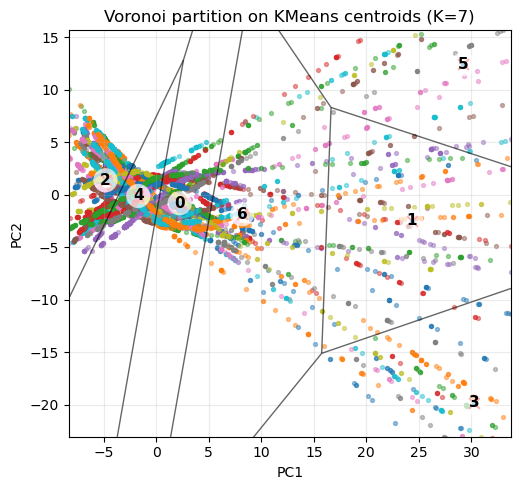

In [30]:
# ---------- 1) Fit ONE KMeans on all runs (2D PCA) ----------
Ztest_all = np.vstack([r["Ztest_pca"] for r in runs])  
X2 = Ztest_all[:, :2]                                   
km = KMeans(n_clusters=K, random_state=SEED, n_init="auto")
km.fit(X2)
centroids = km.cluster_centers_

# ---------- 2) Build Voronoi on centroids ----------
vor = Voronoi(centroids)

# ---------- 3) Assign labels to each point by nearest centroid (Voronoi partition) ----------
for r in runs:
    Zt2 = r["Ztest_pca"][:, :2]
    r["labels_voronoi"] = cdist(Zt2, centroids).argmin(axis=1)  # int labels in [0..K-1]

# ---------- 4) Plot (points, Voronoi edges, centroids) ----------
fig, ax = plt.subplots(figsize=(6, 5))
for i, r in enumerate(runs):
    pts = r["Ztest_pca"][:, :2]
    ax.scatter(pts[:,0], pts[:,1], s=8, alpha=0.45)

# Voronoi edges (draw AFTER points; set limits afterwards so they don't auto-rescale)
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='k', line_alpha=0.6)

# centroids + numeric labels
ax.scatter(centroids[:,0], centroids[:,1], c='red', s=60, marker='x', label='Centroids')
for j, (x, y) in enumerate(centroids):
    ax.text(x, y, str(j), fontsize=11, fontweight='bold',
            ha='center', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='circle'))

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Voronoi partition on KMeans centroids (K={7})")

# (optional) pick a rectangle to zoom on; set AFTER voronoi_plot_2d (it resets limits)
#ax.set_xlim(-10, 70)
#ax.set_ylim(-20, 20)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [32]:
METHODS = {
    "SpeedCP":   {"cover_key": "covers_speedcp", "cut_key": "cutoffs_speedcp", "time_key": "time_speedcp"},
    "CondCP":   {"cover_key": "covers_cc",       "cut_key": "cutoffs_cc",       "time_key": "time_cc"},
    "SplitCP":    {"cover_key": "covers_scp",      "cut_key": "cutoffs_scp",      "time_key": "time_scp"},
    "PCP":        {"cover_key": "covers_pcp",      "cut_key": "cutoffs_pcp",      "time_key": "time_pcp"},
    "RLCP":       {"cover_key": "covers_rlcp",     "cut_key": "cutoffs_rlcp",     "time_key": "time_rlcp"},

    }

# Initialize containers: method -> list (len K) of lists (values per run)
cover_by_cluster = {m: [list() for _ in range(1,K)] for m in METHODS}
cut_by_cluster   = {m: [list() for _ in range(1,K)] for m in METHODS}
time_by_cluster  = {m: [list() for _ in range(1,K)] for m in METHODS}
sizes_by_cluster = [list() for _ in range(1,K)]

for r in runs:
    lab = r["labels_voronoi"]
    for c in range(K-1):
        idx = (lab == c+1)
        sizes_by_cluster[c].append(int(idx.sum()))
        if not idx.any():
            continue

        for method, keys in METHODS.items():
            # coverage (per-point 0/1)
            cov = r.get(keys["cover_key"])
            if cov is not None:
                cov = np.asarray(cov, dtype=float)
                cover_by_cluster[method][c].append(float(np.nanmean(cov[idx])))

            # cutoffs (scalar per run OR per-point)
            cuts = r.get(keys["cut_key"])
            if cuts is not None:
                cuts = np.asarray(cuts, dtype=float)
                if cuts.ndim == 0:
                    cut_val = float(cuts)               # scalar cutoff
                else:
                    cut_val = float(np.nanmean(cuts[idx]))  # mean within cluster
                cut_by_cluster[method][c].append(cut_val)

            # time (scalar per run)
            t = r.get(keys["time_key"])
            if t is not None:
                time_by_cluster[method][c].append(float(t))

In [33]:
def summarize_by_cluster(cover_by_cluster, cut_by_cluster, time_by_cluster, methods, K):
    rows = []
    for method in methods:
        for c in range(K-1):
            cover_vals = np.array(cover_by_cluster[method][c], dtype=float)
            cut_vals   = np.array(cut_by_cluster[method][c], dtype=float)
            time_vals  = np.array(time_by_cluster[method][c], dtype=float)

            row = {
                "Method": method,
                "Partition": c+1,
                "Coverage_mean": np.nanmean(cover_vals) if cover_vals.size > 0 else np.nan,
                "Coverage_sd":   np.nanstd(cover_vals, ddof=1) if cover_vals.size > 1 else np.nan,
                "Cutoff_mean":   np.nanmean(cut_vals) if cut_vals.size > 0 else np.nan,
                "Cutoff_sd":     np.nanstd(cut_vals, ddof=1) if cut_vals.size > 1 else np.nan,
                "Time_mean":     np.nanmean(time_vals) if time_vals.size > 0 else np.nan,
                "Time_sd":       np.nanstd(time_vals, ddof=1) if time_vals.size > 1 else np.nan,
            }
            rows.append(row)

    return pd.DataFrame(rows)

summary_df = summarize_by_cluster(cover_by_cluster, cut_by_cluster, time_by_cluster, METHODS.keys(), K)
print(summary_df)

     Method  Partition  Coverage_mean  Coverage_sd  Cutoff_mean  Cutoff_sd  \
0   SpeedCP          1       0.728707     0.305750     2.124792   0.159198   
1   SpeedCP          2       0.877938     0.038005     1.848355   0.148218   
2   SpeedCP          3       0.933009     0.073720     2.189584   0.304309   
3   SpeedCP          4       0.901418     0.031362     1.571324   0.145930   
4   SpeedCP          5       0.928517     0.105901     2.117008   0.185790   
5   SpeedCP          6       0.825176     0.133477     2.073213   0.193275   
6    CondCP          1       0.882828     0.271637     2.961755   0.512800   
7    CondCP          2       0.723388     0.154956     1.977204   0.614083   
8    CondCP          3       0.986643     0.028465     2.768736   0.227471   
9    CondCP          4       0.809365     0.110708     1.926630   0.529570   
10   CondCP          5       0.976061     0.058512     2.997842   0.512593   
11   CondCP          6       0.916366     0.087317     2.832902 

In [34]:
for method in ["speedcp", "scp", "pcp", "rlcp", "cc"]:
    all_cuts = np.array([r[f"cutoffs_{method}"] for r in runs])
    all_time = np.array([r[f"time_{method}"] for r in runs])
    print(f"Cutoff ({method}): {all_cuts.mean()}, {all_cuts.std()}")
    print(f"Time ({method}): {all_time.mean()}, {all_time.std()}")

Cutoff (speedcp): 1.6949331330936785, 0.44467928720374855
Time (speedcp): 53.46937961356584, 17.449624320582036
Cutoff (scp): 1.909655631522245, 0.10410781114286959
Time (scp): 0.0011210607927899028, 0.005652450609367022
Cutoff (pcp): 2.811740765367552, 2.2884318071168295
Time (pcp): 40.54683949781019, 4.370460298053625
Cutoff (rlcp): 2.6788834746826526, 2.439088704045272
Time (rlcp): 1.1512625716453375, 0.03894577579259832
Cutoff (cc): 2.015795788128136, 1.4264922015499955
Time (cc): 2386.8669669517253, 233.30961808955425


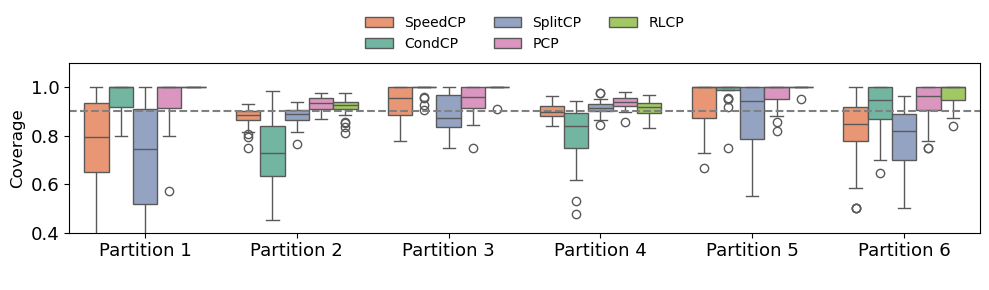

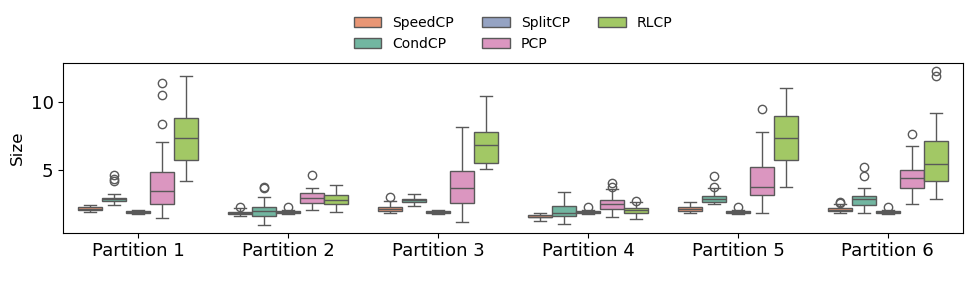

In [35]:
method_names = list(METHODS.keys())
original_palette = sns.color_palette("Set2", n_colors=len(method_names))

reddest_index = max(range(len(original_palette)), key=lambda i: original_palette[i][0])

swapped_palette = original_palette.copy()
swapped_palette[0], swapped_palette[reddest_index] = swapped_palette[reddest_index], swapped_palette[0]
palette = dict(zip(method_names, swapped_palette))

# Create a dataframe for plotting coverage and cutoffs
coverage_data = []
for method in METHODS.keys():
    for c in range(1, K):
        cover_vals = cover_by_cluster[method][c-1]
        cutoff_vals = cut_by_cluster[method][c-1]
        for val in cover_vals:
            coverage_data.append({
                "method": method,
                "shift_type": f"Partition {c}",
                "type": "Coverage",
                "value": val
            })
        for val in cutoff_vals:
            coverage_data.append({
                "method": method,
                "shift_type": f"Partition {c}",
                "type": "Size",
                "value": val
            })
# Create a single plot
fig, ax = plt.subplots(figsize=(10, 3))

coverage_df = pd.DataFrame(coverage_data)
coverage_df["shift_type"] = coverage_df["shift_type"].astype(str)

# Create boxplot
sns.boxplot(data=coverage_df[coverage_df['shift_type'].str.startswith('Partition') & (coverage_df['type'] == 'Coverage')], 
            x="shift_type", y="value", hue="method", 
            palette=palette, ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
ax.set_ylim(0.4, 1.1)
ax.axhline(0.9, color='gray', linestyle='--', label="target miscoverage")
ax.set_xlabel(" ")
ax.set_ylabel("Coverage", fontsize = 12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(data=coverage_df[coverage_df['shift_type'].str.startswith('Partition') & (coverage_df['type'] == 'Size')], 
            x="shift_type", y="value", hue="method", 
            palette=palette, ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
#ax.set_ylim(0.4, 1.1)
ax.set_xlabel(" ")
ax.set_ylabel("Size", fontsize = 12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()

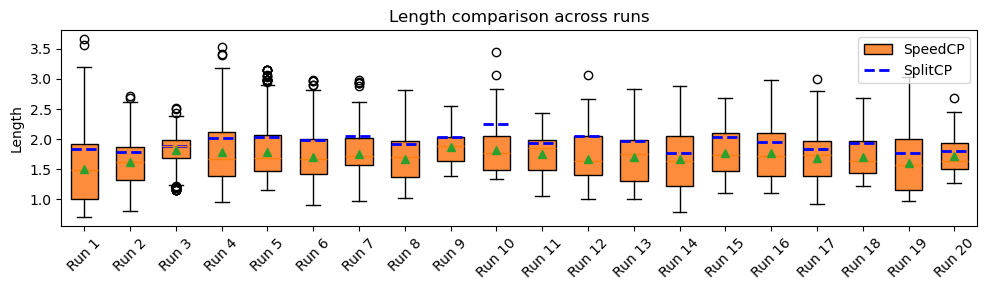

In [36]:
def boxplots_speedcp_vs_scp(runs, title=None, fname=None):
    """
    For each run, plot a boxplot of SpeedCP cutoffs and overlay the
    Split-CP cutoff as a horizontal line.
    - runs: list of dicts with keys:
        - "cutoffs_lakcp": array-like of cutoffs (per cluster or per point)
        - "cutoffs_scp":   scalar cutoff for that run
    """
    n_runs = len(runs)
    lakcp_data = []
    scp_lines = []

    for r in runs:
        lakcp = np.ravel(r["cutoffs_speedcp"])   # ensure 1D
        lakcp_data.append(lakcp)
        scp_lines.append(r["cutoffs_scp"])     # scalar per run

    plt.figure(figsize=(max(6, 0.5*n_runs), 3))

    # Boxplots of LAKCP cutoffs
    bp = plt.boxplot(lakcp_data, positions=np.arange(n_runs), widths=0.6,
                     patch_artist=True, showmeans=True)
    for patch in bp['boxes']:
        patch.set_facecolor("#fd8d3c")

    # Overlay SCP cutoffs as horizontal line segments per run
    for i, scp_val in enumerate(scp_lines):
        plt.hlines(scp_val, i-0.3, i+0.3, colors="blue", linestyles="--", lw=2)

    plt.xticks(np.arange(n_runs), [f"Run {i+1}" for i in range(n_runs)], rotation=45)
    plt.ylabel("Length")
    plt.title(title if title else "Per-run LAKCP cutoff distributions with SCP cutoff")
    legend_handles = [
        bp['boxes'][0],
        Line2D([0], [0], color="blue", linestyle="--", lw=2)
    ]
    plt.legend(legend_handles, ["SpeedCP", "SplitCP"], loc="upper right")

    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=160)
    plt.show()
boxplots_speedcp_vs_scp(runs[:20], title="Length comparison across runs")